In [161]:
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [162]:
!ls /content/drive/


MyDrive  Shareddrives


In [163]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
import os
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

## Dataset

In [164]:
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# print(f"Fichier '{filename}' uploade")
df = pd.read_csv('/content/drive/MyDrive/python/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Dataset loaded!")

Dataset loaded!


In [165]:
# df = pd.read_csv(filename)
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [166]:
df.shape

(1470, 35)

In [167]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [168]:
df.describe(include="all")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [169]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# single unique value

In [170]:
single_value_cols = df.columns[df.nunique() == 1]

print(single_value_cols.tolist())

['EmployeeCount', 'Over18', 'StandardHours']


In [171]:
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)


In [172]:
business_features = [
    'JobLevel',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'PercentSalaryHike',
    'StockOptionLevel',
    'MonthlyIncome',
    'MonthlyRate',
    'HourlyRate',
    'DailyRate',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
    'NumCompaniesWorked',
    'OverTime',
    'JobRole',
    'Department',
    'WorkLifeBalance',
    'EducationField',
    'JobInvolvement',
    'PerformanceRating'
]

df = df.drop(columns=business_features, errors='ignore')


In [173]:
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,Yes,Travel_Rarely,1,2,Female,Single,8,0
1,49,No,Travel_Frequently,8,1,Male,Married,10,3
2,37,Yes,Travel_Rarely,2,2,Male,Single,7,3
3,33,No,Travel_Frequently,3,4,Female,Married,8,3
4,27,No,Travel_Rarely,2,1,Male,Married,6,3


In [174]:
print("Remaining features:", df.shape[1])


Remaining features: 9


In [175]:
df.shape

(1470, 9)

# columns classification

In [176]:
target = ['Attrition']

quantitative = [
    'Age',
    'DistanceFromHome',
    'TotalWorkingYears',
    'TrainingTimesLastYear'
]

ordinal = [
    'Education',
]

nominal = [
    'BusinessTravel',
    'Gender',
    'MaritalStatus',
]


In [177]:
set(df.columns) == set(target + quantitative + ordinal + nominal)

True

# EDA

target


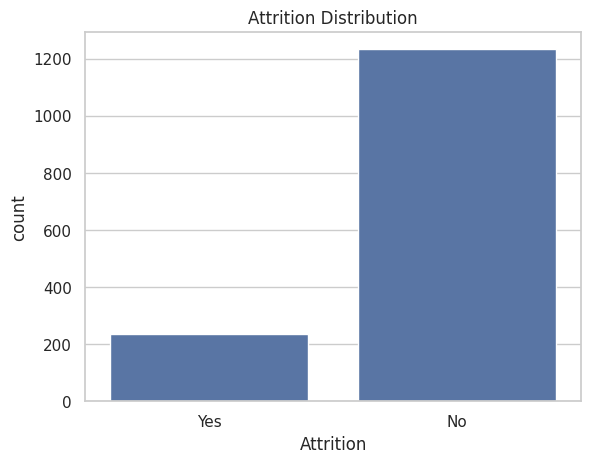

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [178]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

df['Attrition'].value_counts(normalize=True) * 100

nominal

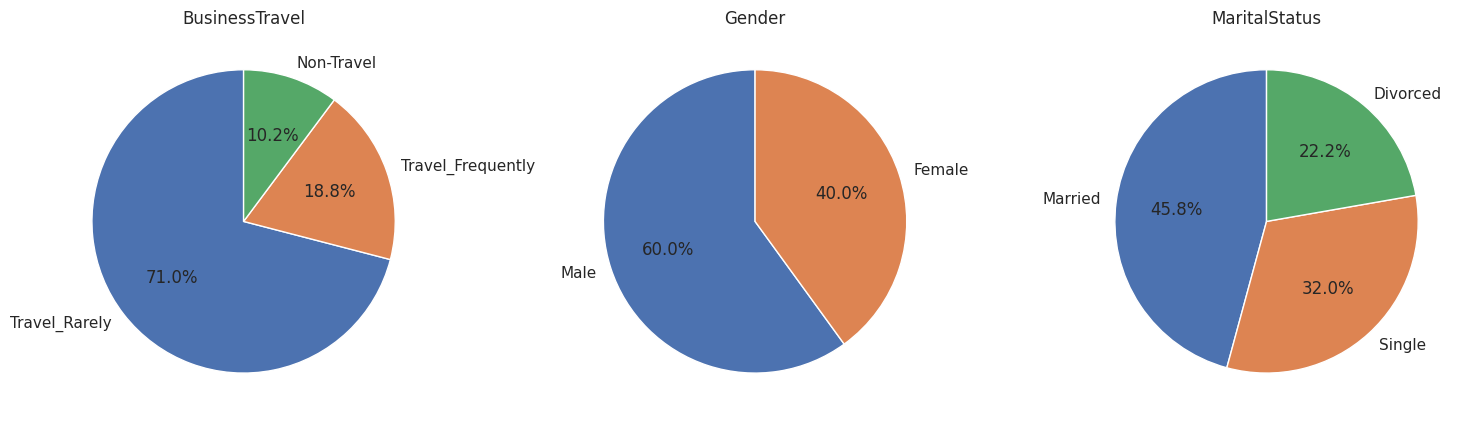

In [179]:

cols = nominal
n = len(cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*5))

axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].value_counts().plot.pie(
        ax=axes[i],
        autopct='%1.1f%%',
        startangle=90,
        title=col
    )
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


ordinal

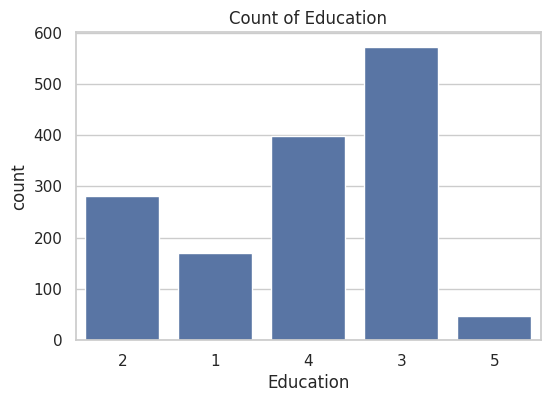

In [180]:
for col in ordinal:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].unique())
    plt.title(f"Count of {col}")
    plt.show()

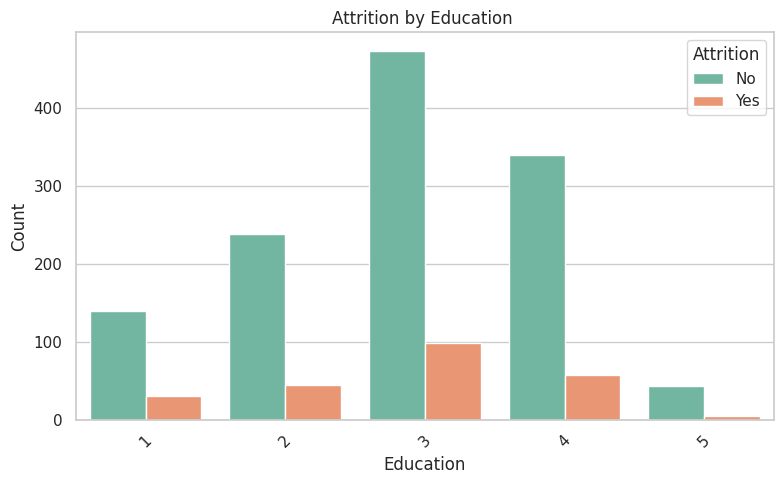

In [181]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x='Education', hue='Attrition', data=df, palette='Set2')

plt.title("Attrition by Education ")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


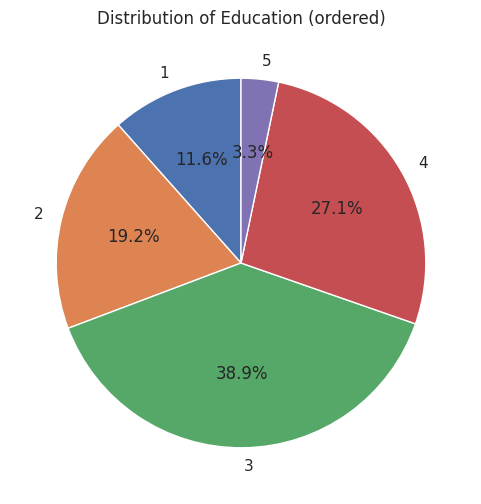

In [182]:
for col in ordinal:
    counts = df[col].value_counts().sort_index()

    plt.figure(figsize=(6,6))
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f"Distribution of {col} (ordered)")
    plt.show()


Distribution plots

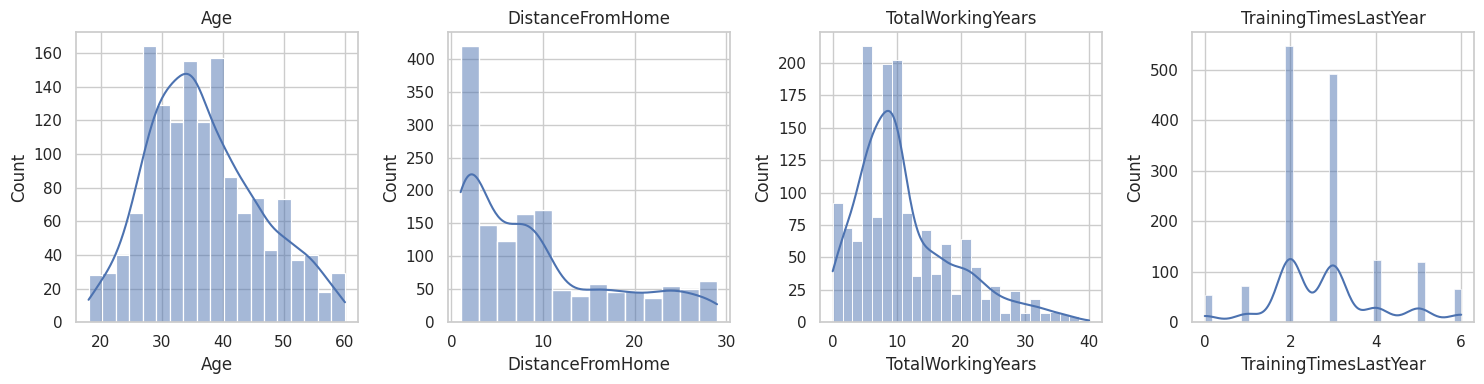

In [183]:
n_cols = 4
n_rows = math.ceil(len(quantitative)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Correlation

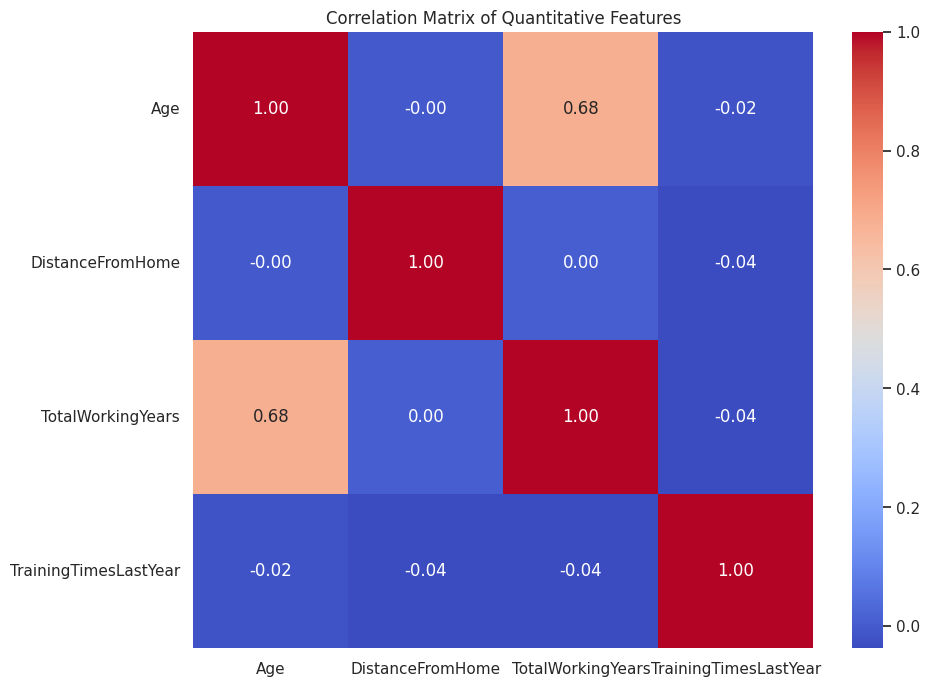

In [184]:
corr = df[quantitative].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Quantitative Features")
plt.show()


Attrition vs features

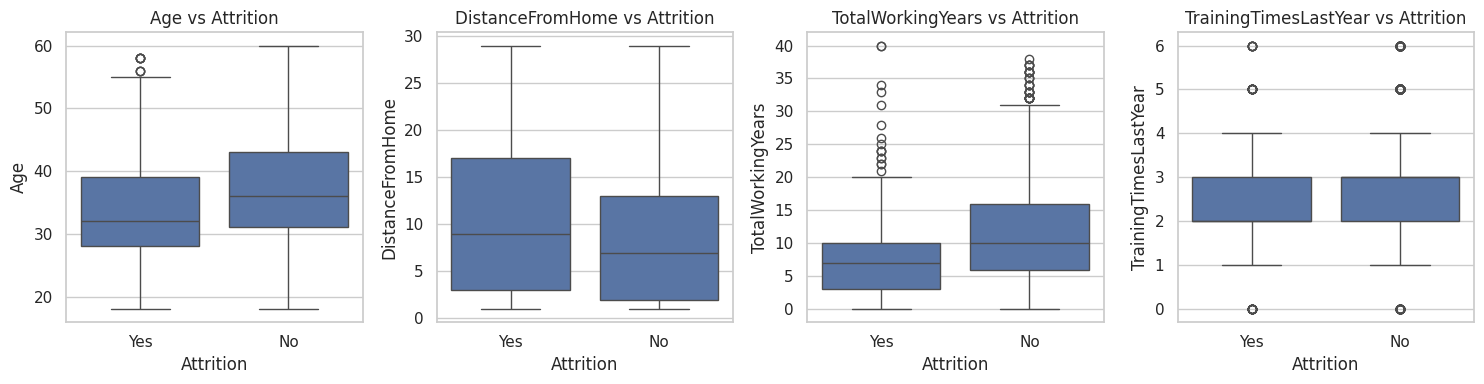

In [185]:
# Continuous features
n_cols = 4
n_rows = math.ceil(len(quantitative)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(quantitative):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Attrition")

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


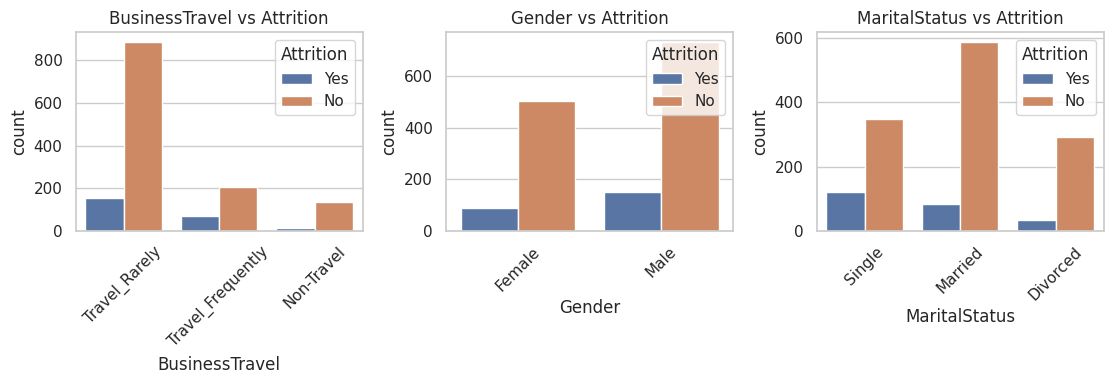

In [186]:
# Categorical features
n_cols = 4
n_rows = math.ceil(len(nominal)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(nominal):
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Attrition")
    axes[i].tick_params(axis='x', rotation=45)

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Check skewed / imbalanced features

In [187]:
df[quantitative].skew().sort_values(ascending=False)


,0
TotalWorkingYears,1.117172
DistanceFromHome,0.958118
TrainingTimesLastYear,0.553124
Age,0.413286


pairplot / scatter matrix

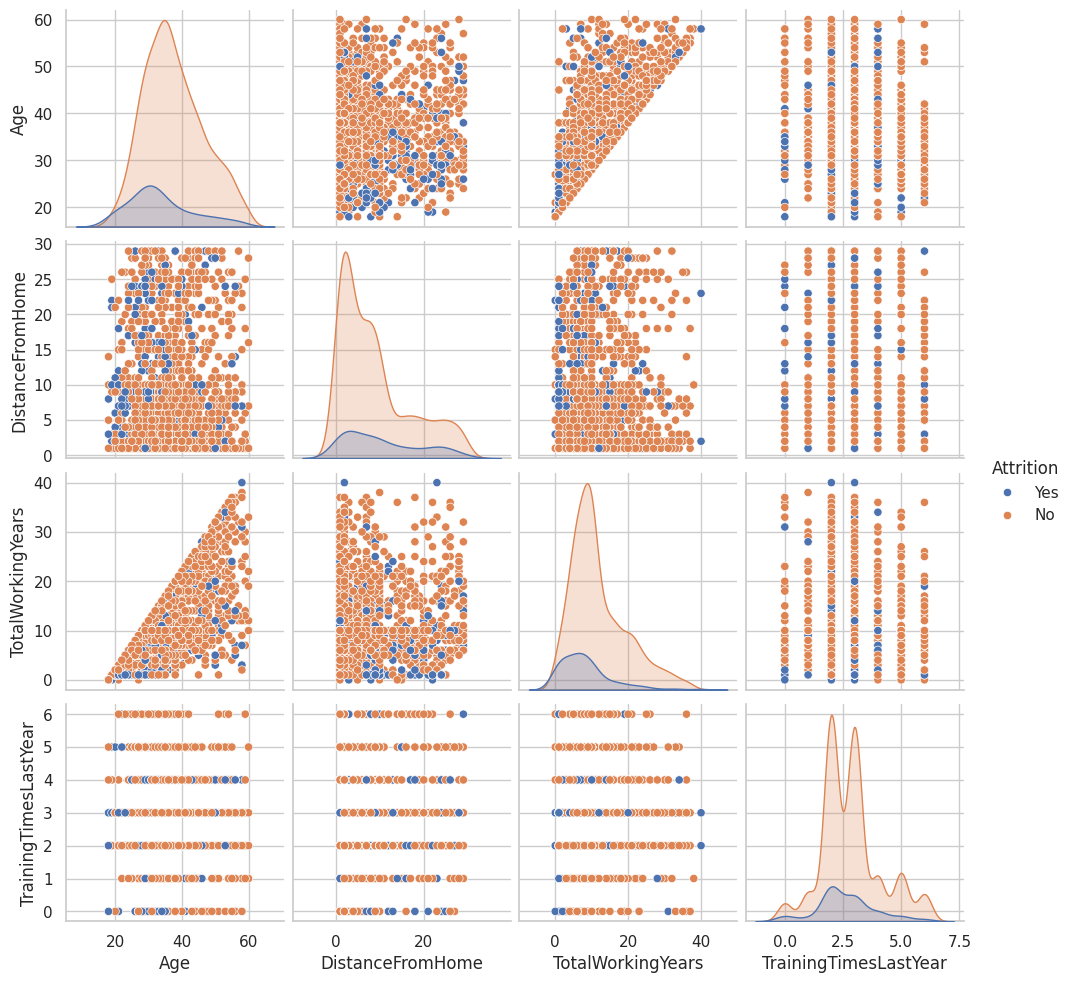

In [188]:
sns.pairplot(df[quantitative + ['Attrition']], hue='Attrition')
plt.show()


# missing values

In [189]:
(df.isnull().mean() * 100)


,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DistanceFromHome,0.0
Education,0.0
Gender,0.0
MaritalStatus,0.0
TotalWorkingYears,0.0
TrainingTimesLastYear,0.0


# outliers

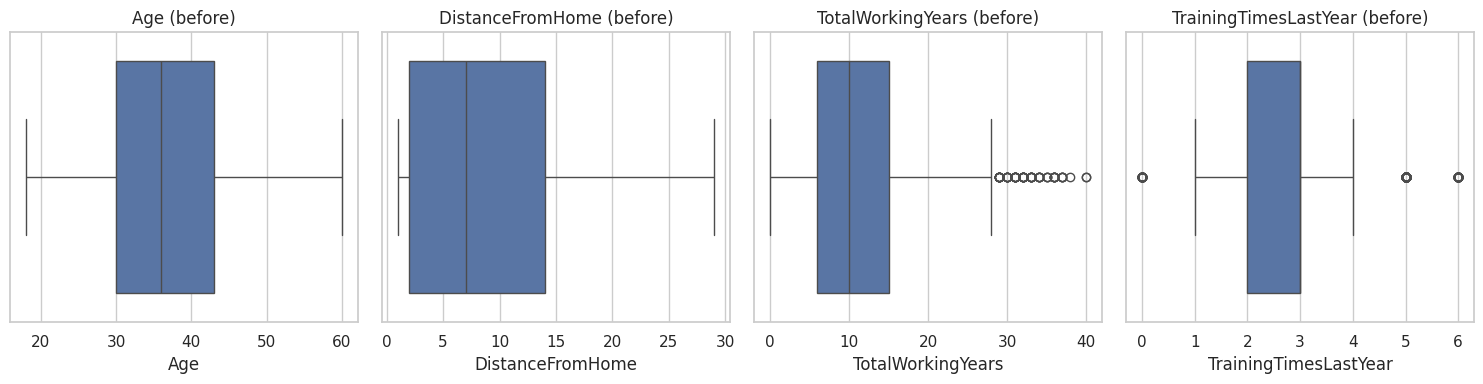

In [190]:
n_cols = 4
n_rows = math.ceil(len(quantitative) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
df_before = df.copy()

for i, col in enumerate(quantitative):
    sns.boxplot(x=df_before[col], ax=axes[i])
    axes[i].set_title(f"{col} (before)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

In [191]:
outlier_percentages = {}

for col in quantitative:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    percentage = (len(outliers) / len(df)) * 100

    outlier_percentages[col] = percentage


outlier_df = pd.DataFrame.from_dict(
    outlier_percentages,
    orient='index',
    columns=['Outlier Percentage (%)']
)

outlier_df = outlier_df.sort_values(by='Outlier Percentage (%)', ascending=False)
outlier_df


,Outlier Percentage (%)
TrainingTimesLastYear,16.190476
TotalWorkingYears,4.285714
DistanceFromHome,0.000000
Age,0.000000


# Encoding

In [192]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DistanceFromHome', 'Education',
       'Gender', 'MaritalStatus', 'TotalWorkingYears',
       'TrainingTimesLastYear'],
      dtype='object')

Target

In [193]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})

nominal

In [194]:
label_encoders = {}

for col in nominal:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    # save mapping
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))


In [195]:
clean_label_encoders = {
    col: {int(k) if isinstance(k, (np.integer, int)) else k: int(v) for k, v in mapping.items()}
    for col, mapping in label_encoders.items()
}

In [196]:
save_path = '/content/drive/MyDrive/python/label_encoders.pkl'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the dictionary
with open(save_path, 'wb') as f:
    pickle.dump(clean_label_encoders, f)

print(f"Label encoders saved to {save_path}")

Label encoders saved to /content/drive/MyDrive/python/label_encoders.pkl


In [197]:
with open(save_path, 'rb') as f:
    loaded_encoders = pickle.load(f)

print(loaded_encoders)

{'BusinessTravel': {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}, 'Gender': {'Female': 0, 'Male': 1}, 'MaritalStatus': {'Divorced': 0, 'Married': 1, 'Single': 2}}


In [198]:
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,2,8,0
1,49,0,1,8,1,1,1,10,3
2,37,1,2,2,2,1,2,7,3
3,33,0,1,3,4,0,1,8,3
4,27,0,2,2,1,1,1,6,3


In [199]:
df.shape

(1470, 9)

In [200]:
# df.to_csv("cleanedData.csv", index=False)
# files.download("cleanedData.csv")

df.to_csv('/content/drive/MyDrive/python/cleanedDataset.csv', index=False)
print(f"Dataset saved to: /content/drive/MyDrive/python")

Dataset saved to: /content/drive/MyDrive/python
